## Best Combination CV

In [1]:
from Pipeline.Algorithm.ArtificialBeeColonyElmCV import ArtificialBeeColonyElmCV
from Pipeline.Global.GallstoneDataSet import GallstoneDataSet
from Pipeline.Global.GlobalSetting import GlobalSetting
from Pipeline.Global.Plotting import Plotting
from Pipeline.Optimization.ABC_Testing import abc_testing

In [2]:
gallstone_dataset = GallstoneDataSet()
gallstone_dataset.fetch_data_path_1()

features_size = gallstone_dataset.x_train.shape[1]
x_train = gallstone_dataset.x_train
x_test  = gallstone_dataset.x_test
y_train = gallstone_dataset.y_train
y_test  = gallstone_dataset.y_test

In [3]:
mod = "Grid_Combination"

In [4]:
best_lambda_config = GlobalSetting.get_config_by_type(mod)
best_lamda_hidden_size = best_lambda_config["Hidden_Nodes"] if best_lambda_config else None
best_lamda_lambda_value = best_lambda_config["Lambda_Value"] if best_lambda_config else None

In [5]:
abc_relm_cv  = ArtificialBeeColonyElmCV(
    features_size       = features_size,
    hidden_size         = best_lamda_hidden_size,
    activation_function = GlobalSetting.sigmoid             ,
    regularization_lambda=best_lamda_lambda_value           ,
    fitness_function    = GlobalSetting.evaluation_function ,
    solution_size       = GlobalSetting.solution_size       ,
    trial_limit         = GlobalSetting.trial_limit         ,
    max_iteration       = GlobalSetting.max_iteration
)

In [6]:
results_df , convergence_df , scout_df = abc_testing(abc_relm_cv, x_train, y_train, x_test, y_test)
results_df.describe()

Seed 41 start

Iteration 1 end : 0.1259s | Scout Triggers: 0
Iteration 2 end : 0.1295s | Scout Triggers: 0
Iteration 3 end : 0.1235s | Scout Triggers: 0
Iteration 4 end : 0.1226s | Scout Triggers: 0
Iteration 5 end : 0.1171s | Scout Triggers: 0
Iteration 6 end : 0.1239s | Scout Triggers: 0
Iteration 7 end : 0.1195s | Scout Triggers: 0
Iteration 8 end : 0.1226s | Scout Triggers: 0
Iteration 9 end : 0.1271s | Scout Triggers: 0
Iteration 10 end : 0.1280s | Scout Triggers: 0
Iteration 11 end : 0.1196s | Scout Triggers: 0
Iteration 12 end : 0.1213s | Scout Triggers: 1
Iteration 13 end : 0.1247s | Scout Triggers: 0
Iteration 14 end : 0.1275s | Scout Triggers: 0
Iteration 15 end : 0.1218s | Scout Triggers: 0
Iteration 16 end : 0.1288s | Scout Triggers: 0
Iteration 17 end : 0.1383s | Scout Triggers: 1
Iteration 18 end : 0.1451s | Scout Triggers: 0
Iteration 19 end : 0.1398s | Scout Triggers: 1
Iteration 20 end : 0.1325s | Scout Triggers: 0
Iteration 21 end : 0.1507s | Scout Triggers: 2
Iterati

,Accuracy,Precision,Recall,NPV,Specificity,F1-Score,F2-Score,Bal Accuracy,MCC,ABC_Seed
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.777604,0.780595,0.773958,0.777077,0.781250,0.776376,0.774716,0.777604,0.556435,55.500000
std,0.030620,0.033533,0.049023,0.037277,0.042643,0.033128,0.041535,0.030620,0.060822,8.803408
min,0.703125,0.714286,0.656250,0.685714,0.687500,0.688525,0.668790,0.703125,0.408047,41.000000
25%,0.750000,0.757576,0.750000,0.757837,0.750000,0.751894,0.755911,0.750000,0.501723,48.250000
50%,0.781250,0.781250,0.781250,0.777722,0.781250,0.777722,0.778824,0.781250,0.562500,55.500000
75%,0.796875,0.807382,0.812500,0.803368,0.812500,0.804839,0.803761,0.796875,0.599944,62.750000
max,0.843750,0.843750,0.875000,0.851852,0.843750,0.843750,0.848485,0.843750,0.687500,70.000000


[I/O Trace] Figure exported successfully: ../../Storage/Figure\ABC_Telemetry_Grid_Combination_CV_F1-Score.png


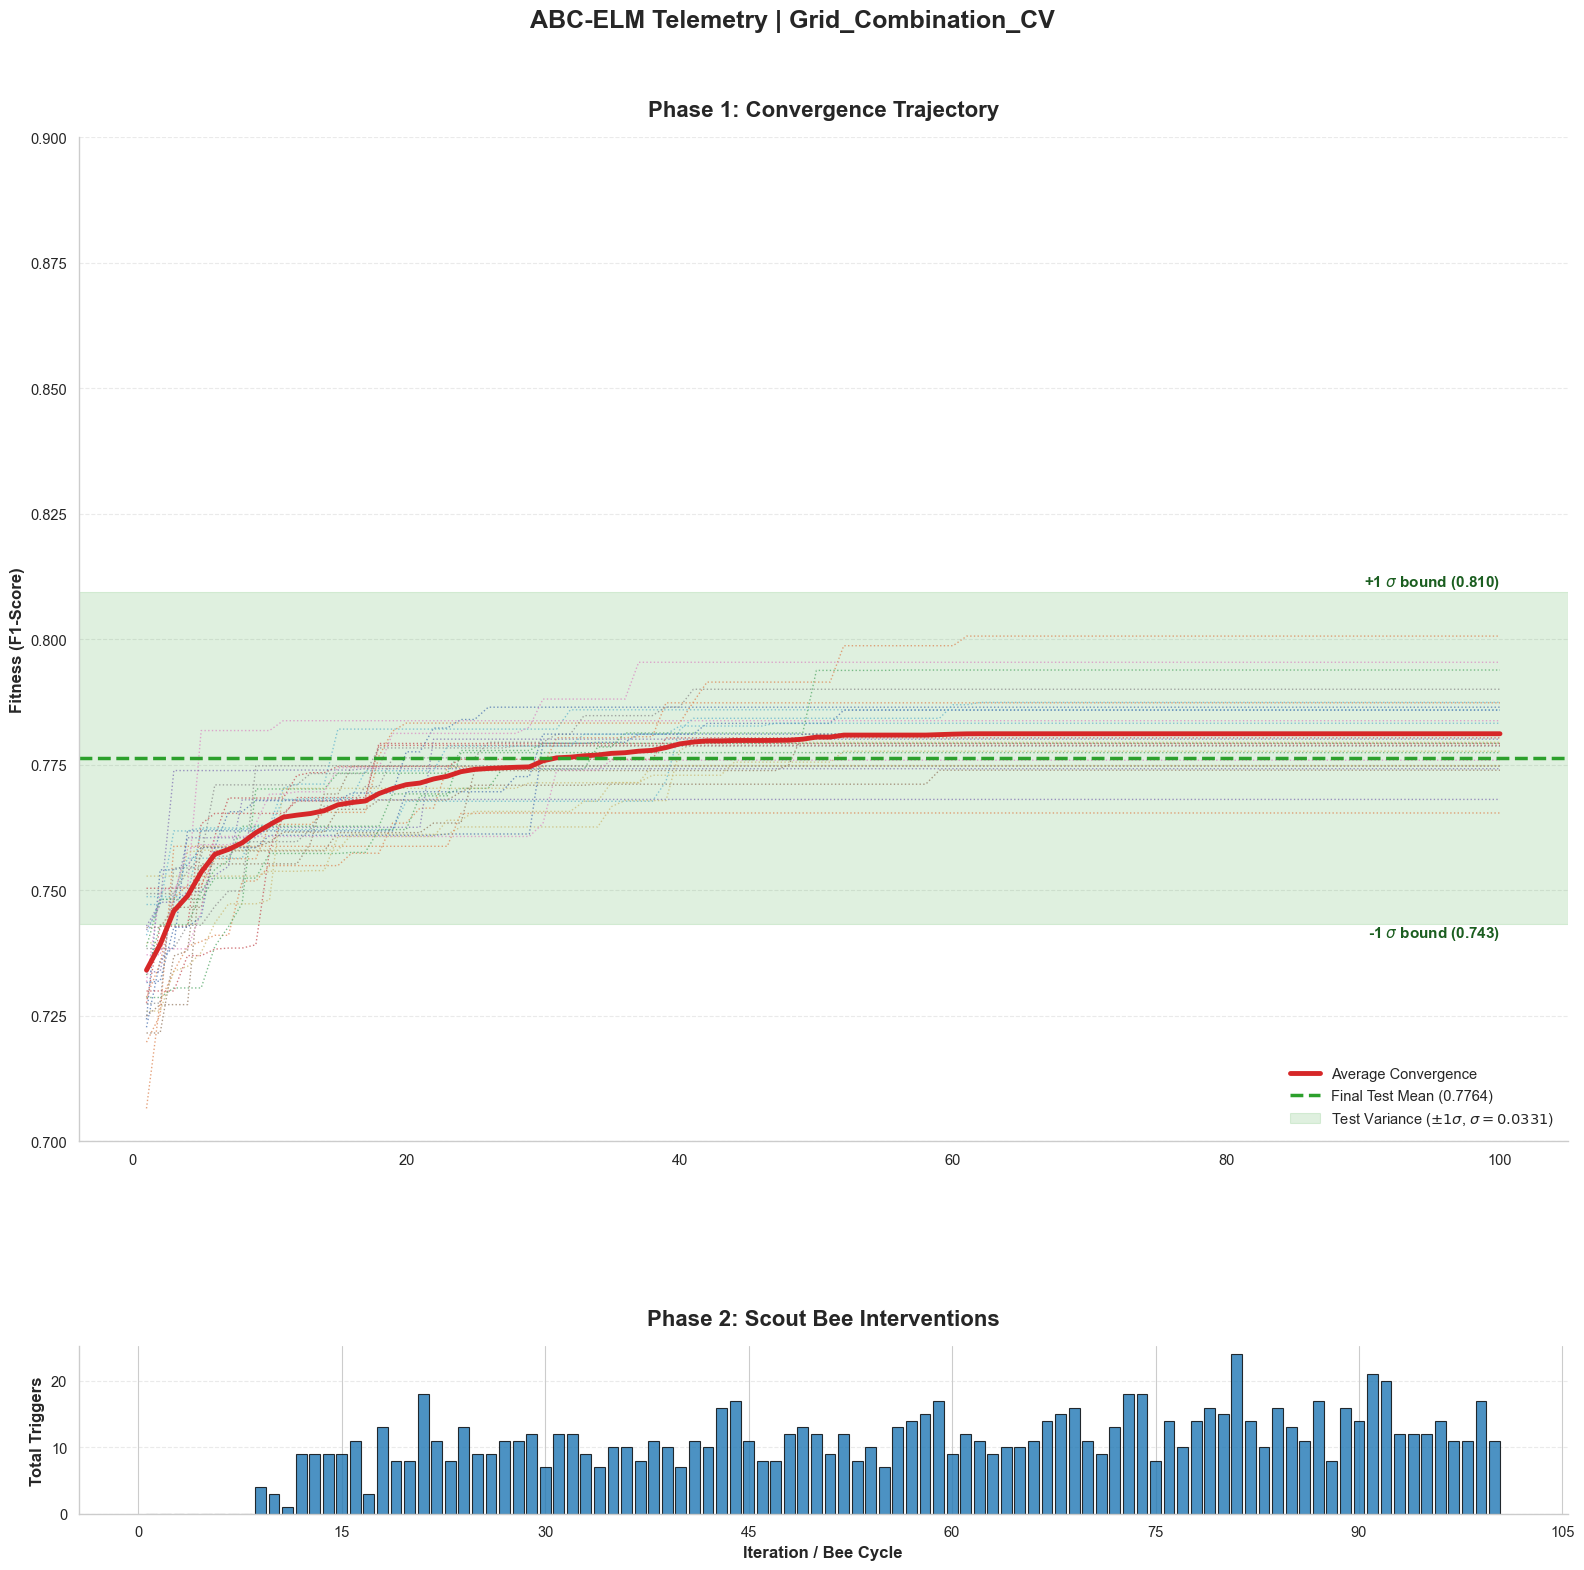

In [7]:
Plotting.plot_abc_dashboard(convergence_df,scout_df,f"{mod}_CV",results_df,is_final_record=True)

In [8]:
GlobalSetting.save_dataframe_to_record(results_df, f"ABC_{mod}_Results.csv")

GlobalSetting.save_dataframe_to_record(convergence_df, f'ABC_{mod}_Convergence.csv')

GlobalSetting.save_dataframe_to_record(scout_df, f'ABC_{mod}_Scout_History.csv')

[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Combination_Results.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Combination_Convergence.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Combination_Scout_History.csv
